In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Simple plotting for benchmark results

In [8]:
df = pd.read_csv('output/benchmark_results.csv')
df

,method,num_processes,points,elapsed_s
0,serial,1,48,0.000612
1,mpi,2,48,0.000651
2,mpi,4,48,0.001138
3,mpi,8,48,0.001200
4,serial,1,240,0.002223
5,mpi,2,240,0.002560
6,mpi,4,240,0.002642
7,mpi,8,240,0.004577
8,serial,1,480,0.004516
9,mpi,2,480,0.004709


In [9]:
serial = df[df['method'] == 'serial']
mpi_2 = df[(df['method'] == 'mpi') & (df['num_processes'] == 2)]
mpi_4 = df[(df['method'] == 'mpi') & (df['num_processes'] == 4)]
mpi_8 = df[(df['method'] == 'mpi') & (df['num_processes'] == 8)]

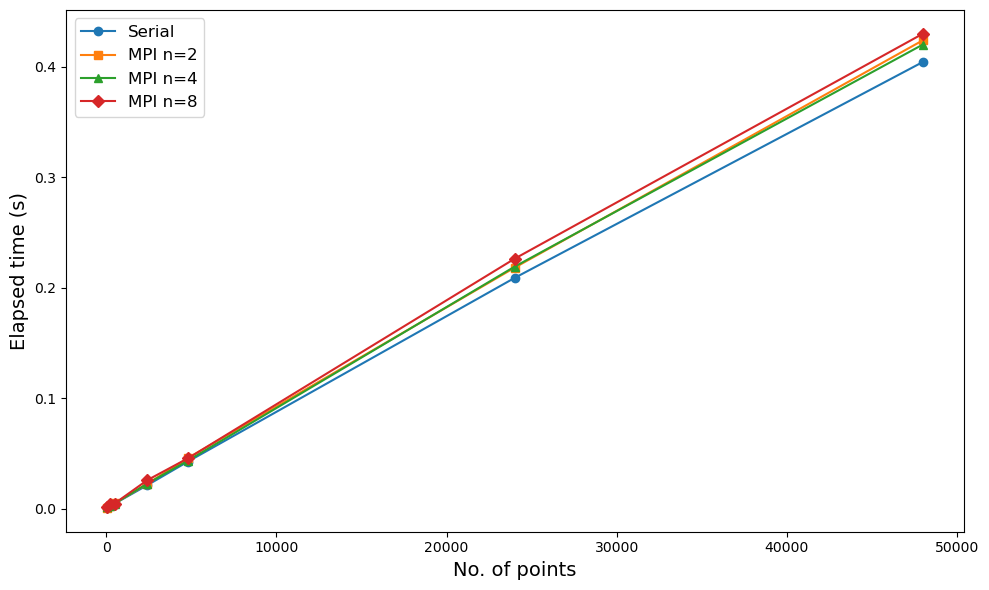

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(serial['points'], serial['elapsed_s'], 'o-', label='Serial')
plt.plot(mpi_2['points'].values, mpi_2['elapsed_s'].values, 's-', label='MPI n=2')
plt.plot(mpi_4['points'].values, mpi_4['elapsed_s'].values, '^-', label='MPI n=4')
plt.plot(mpi_8['points'].values, mpi_8['elapsed_s'].values, 'D-', label='MPI n=8')

plt.xlabel('No. of points', fontsize=14)
plt.ylabel('Elapsed time (s)', fontsize=14)
plt.legend(fontsize=12)

plt.tight_layout()

# plt.savefig('output/benchmark_time.svg')
plt.show()

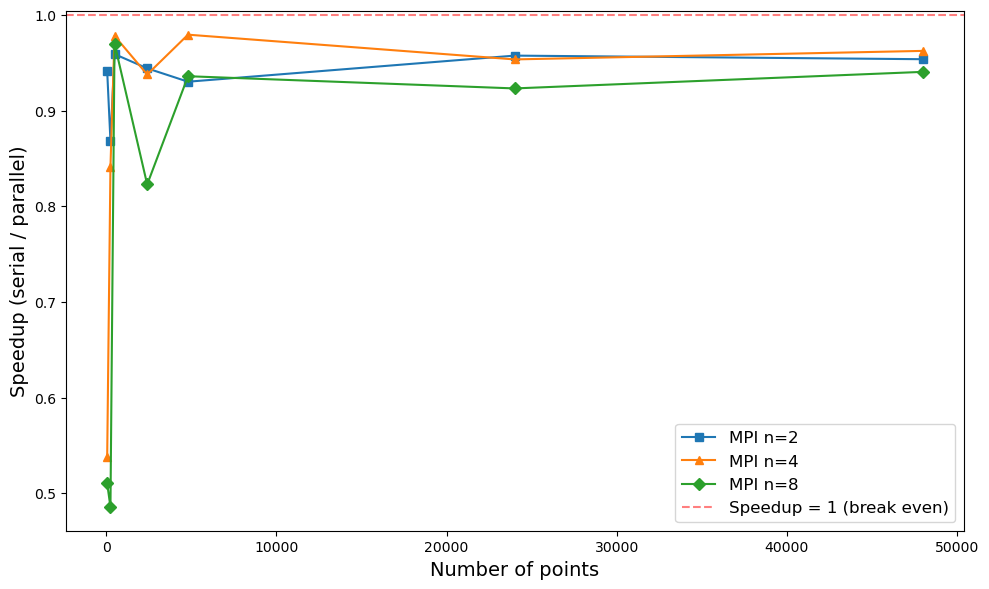

In [11]:
plt.figure(figsize=(10, 6))

serial_times = serial.set_index('points')['elapsed_s']

for np_val, label, marker in [(2, 'MPI n=2', 's-'), (4, 'MPI n=4', '^-'), (8, 'MPI n=8', 'D-')]:
    mpi_subset = df[(df['method'] == 'mpi') & (df['num_processes'] == np_val)]
    speedup = [serial_times[p] / t for p, t in zip(mpi_subset['points'], mpi_subset['elapsed_s'])]
    plt.plot(mpi_subset['points'].values, speedup, marker, label=label)

plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Speedup = 1 (break even)')
plt.xlabel('Number of points', fontsize=14)
plt.ylabel('Speedup (serial / parallel)', fontsize=14)

plt.legend(fontsize=12)

plt.tight_layout()

plt.show()

In [12]:
print(f"{'Points':<10} {'Serial (s)':<14} {'MPI-2 (s)':<14} {'MPI-4 (s)':<14} {'MPI-8 (s)':<14} {'Best speedup':<14}")
print('-' * 80)
for _, row in serial.iterrows():
    p = row['points']
    t_serial = row['elapsed_s']
    t2 = mpi_2[mpi_2['points'] == p]['elapsed_s'].values[0]
    t4 = mpi_4[mpi_4['points'] == p]['elapsed_s'].values[0]
    t8 = mpi_8[mpi_8['points'] == p]['elapsed_s'].values[0]
    best = t_serial / min(t2, t4, t8)
    print(f"{int(p):<10} {t_serial:<14.6f} {t2:<14.6f} {t4:<14.6f} {t8:<14.6f} {best:<14.2f}")

Points     Serial (s)     MPI-2 (s)      MPI-4 (s)      MPI-8 (s)      Best speedup  
--------------------------------------------------------------------------------
48         0.000612       0.000651       0.001138       0.001200       0.94          
240        0.002223       0.002560       0.002642       0.004577       0.87          
480        0.004516       0.004709       0.004617       0.004655       0.98          
2400       0.021223       0.022477       0.022632       0.025792       0.94          
4800       0.042718       0.045923       0.043618       0.045641       0.98          
24000      0.208971       0.218250       0.219159       0.226357       0.96          
48000      0.404502       0.424129       0.420296       0.430092       0.96          
